Solar energy generation is one of fastest growing and most promising renewable energy sources of power generation worldwide. Nowadays, the electrical energy becomes one of the basic needs in our daily life, which makes increasing demand for it.
As a major source of electrical power generation fossil fuels are depleting day by day and also its usage raises serious environmental concerns. These reasons force the development of new energy sources which are renewable and ecologically safe.
There are several applications that use solar power, here is the information on the generation of electricity through PV cells. The solar power generation is the most efficient route for power generation because it takes a minimum number of steps (for producing electricity) than that of other generation methods. When the PV modules are exposed to sunlight, they generate direct current. It is one of the best ways in nowadays which can transfer the solar energy into utilization. 
However, the estimation of the PV generation is a challenge because the PV system generation is greatly affected by the weather conditions.
As the weather has great influence on the production of PV systems, such as irradiation, temperature, humidity, wind velocity. The goal of this project is to build the relationship between the weather with the production of PV systems by analyzing history data. Through the model, we are able to use predicted data of weather in the near future to predict the production of PV systems. Once the result deviate much from prediction, probably there are problems with PV system, and the reason need to be figured out, and then adopt proper measure to fix the PV system and make better decisions.

#### About the datasetColumns:
1. Windspeed
2. Sunshine
3. AirPressure
4. Radiation
5. Airtemperature
6. RelativeAirHumidity
7. SystemProduction (Target)
      

Import the libraries

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from statsmodels.api import qqplot
from scipy.stats import shapiro, normaltest, kurtosis, skew
from statsmodels.stats.diagnostic import lilliefors
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_regression, RFECV
import joblib
import os

In [200]:
df = pd.read_csv("Solar Power Plant Data.csv")
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [201]:
df.shape

(8760, 8)

# Data Wrangling

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [203]:
#check missing values
df.isnull().sum()

Date-Hour(NMT)         0
WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
dtype: int64

there is no missing value in the dataset

In [204]:
# Changing 'date-hour' column datatype
df['DateHour'] = pd.to_datetime(df['Date-Hour(NMT)'], format="%d.%m.%Y-%H:%M")
df.drop(columns=['Date-Hour(NMT)'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   WindSpeed            8760 non-null   float64       
 1   Sunshine             8760 non-null   int64         
 2   AirPressure          8760 non-null   float64       
 3   Radiation            8760 non-null   float64       
 4   AirTemperature       8760 non-null   float64       
 5   RelativeAirHumidity  8760 non-null   int64         
 6   SystemProduction     8760 non-null   float64       
 7   DateHour             8760 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 547.6 KB


In [205]:
#setting datehour column as index
df.set_index('DateHour', inplace=True)

In [206]:
# extracting the data from 'DateHour' for our analysis
df['Hour'] = df.index.hour
df['Month'] = df.index.month
df['DayOfYear'] = df.index.dayofyear
df['Year'] = df.index.year

df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Month,DayOfYear,Year
DateHour,,,,,,,,,,,
2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,0,1,1,2017
2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,1,1,1,2017
2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,2,1,1,2017
2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,3,1,1,2017
2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0,4,1,1,2017


We can see there are some negative values in radiation, but radiations can not be negative. This might be due to wrong data collection during the night time. So we will convet it into zero.

In [207]:
df.loc[df['Radiation']<=0].shape

(4470, 11)

Approximately 50% of the radiation values are less than or equal to zero. We can set negative values to zero

In [208]:
df.loc[df['Radiation']<0, 'Radiation'] = 0
df[df['Radiation']<0]

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Month,DayOfYear,Year
DateHour,,,,,,,,,,,


Now, there are no values with radiation less than zero.

# Exploratory Data Analysis

In [209]:
df.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Month,DayOfYear,Year
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.0
mean,2.639823,11.180479,1010.361781,100.594087,6.978893,76.719406,684.746071,11.500000,6.526027,183.000000,2017.0
std,1.628754,21.171295,12.793971,180.614494,7.604266,19.278996,1487.454665,6.922582,3.448048,105.372043,0.0
min,0.000000,0.000000,965.900000,0.000000,-12.400000,13.000000,0.000000,0.000000,1.000000,1.000000,2017.0
25%,1.400000,0.000000,1002.800000,0.000000,0.500000,64.000000,0.000000,5.750000,4.000000,92.000000,2017.0
50%,2.300000,0.000000,1011.000000,0.000000,6.400000,82.000000,0.000000,11.500000,7.000000,183.000000,2017.0
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950,17.250000,10.000000,274.000000,2017.0
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000,23.000000,12.000000,365.000000,2017.0


* 50% of the Radiation has 0 value, as expected from the previous discussion.
* There is a heavy scale difference in the dataset, e.g. Windspeed ranges from 0-10 while system production goes from 0-7701. Linear regression model may struggle here without proper scaling, but models like XGB and RF can handle this type of data. We will prove this further.
* The Hour, Month and DayOfYear columns indicates that this data is for 24 hours, means it is an hourly data for the one year(2017). So we may drop year column.

In [210]:
df.drop(columns='Year', inplace=True)

In [211]:
df['Month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [212]:
# Analysing average monthly radiation 
monthly_rad_avg = df.groupby('Month')['Radiation'].mean()
monthly_sunshine_avg= df.groupby('Month')['Sunshine'].mean()
month_num = df['Month'].unique()
monthly_rad_avg

Month
1      10.794220
2      34.122321
3      86.334409
4     150.530139
5     189.255511
6     207.361250
7     208.895699
8     167.866532
9      70.118889
10     50.229973
11     20.551528
12      6.125672
Name: Radiation, dtype: float64

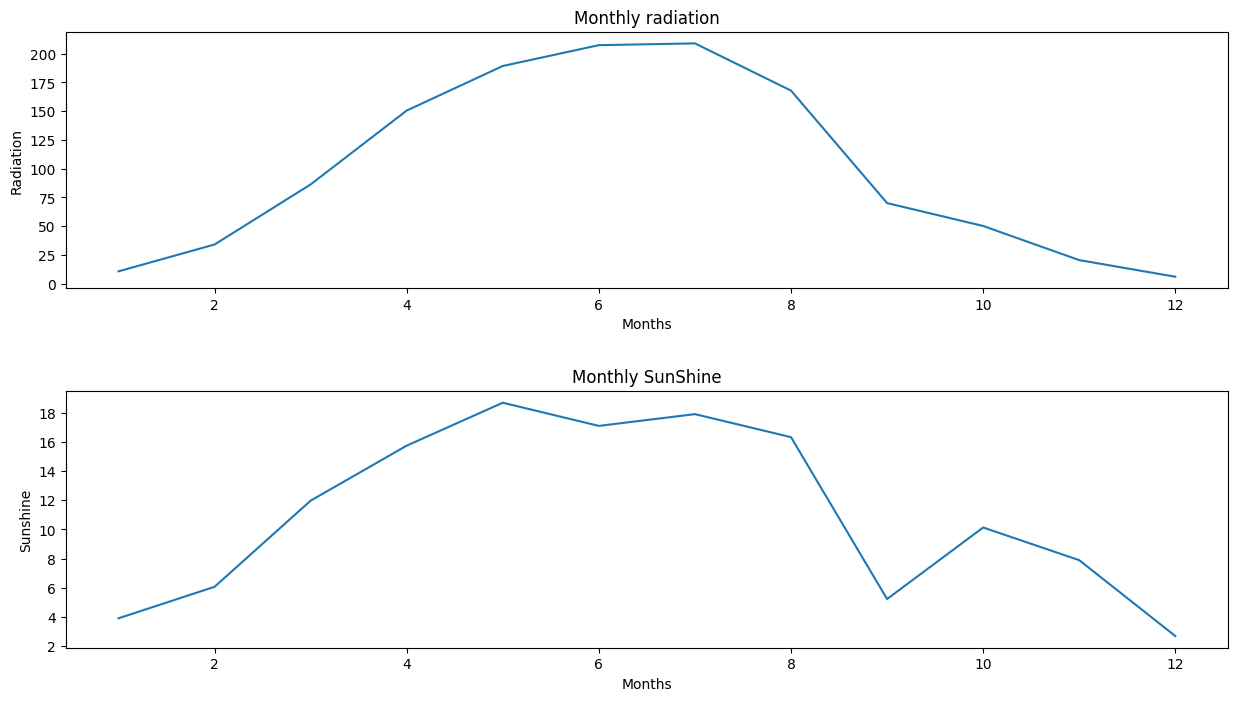

In [213]:
fig, ax = plt.subplots(2,1, figsize=(15,8))

ax[0].set_title('Monthly radiation')
ax[0].set_xlabel('Months')
ax[0].set_ylabel('Radiation')

ax[1].set_title('Monthly SunShine')
ax[1].set_xlabel('Months')
ax[1].set_ylabel('Sunshine')

ax[0].plot(month_num, monthly_rad_avg)
ax[1].plot(month_num, monthly_sunshine_avg)
fig.subplots_adjust(hspace=0.4) 
plt.show()

this curve shows the seasonal variation of Sunshine and Radiation. The peak for the months of june-july suggest power generation from solar is most efficient for these months. The sudden dip in theseptember in Sunshine curve might be due the monsoon clouds.

Plot Histogram for all variables

In [214]:
df.columns

Index(['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature',
       'RelativeAirHumidity', 'SystemProduction', 'Hour', 'Month',
       'DayOfYear'],
      dtype='object')

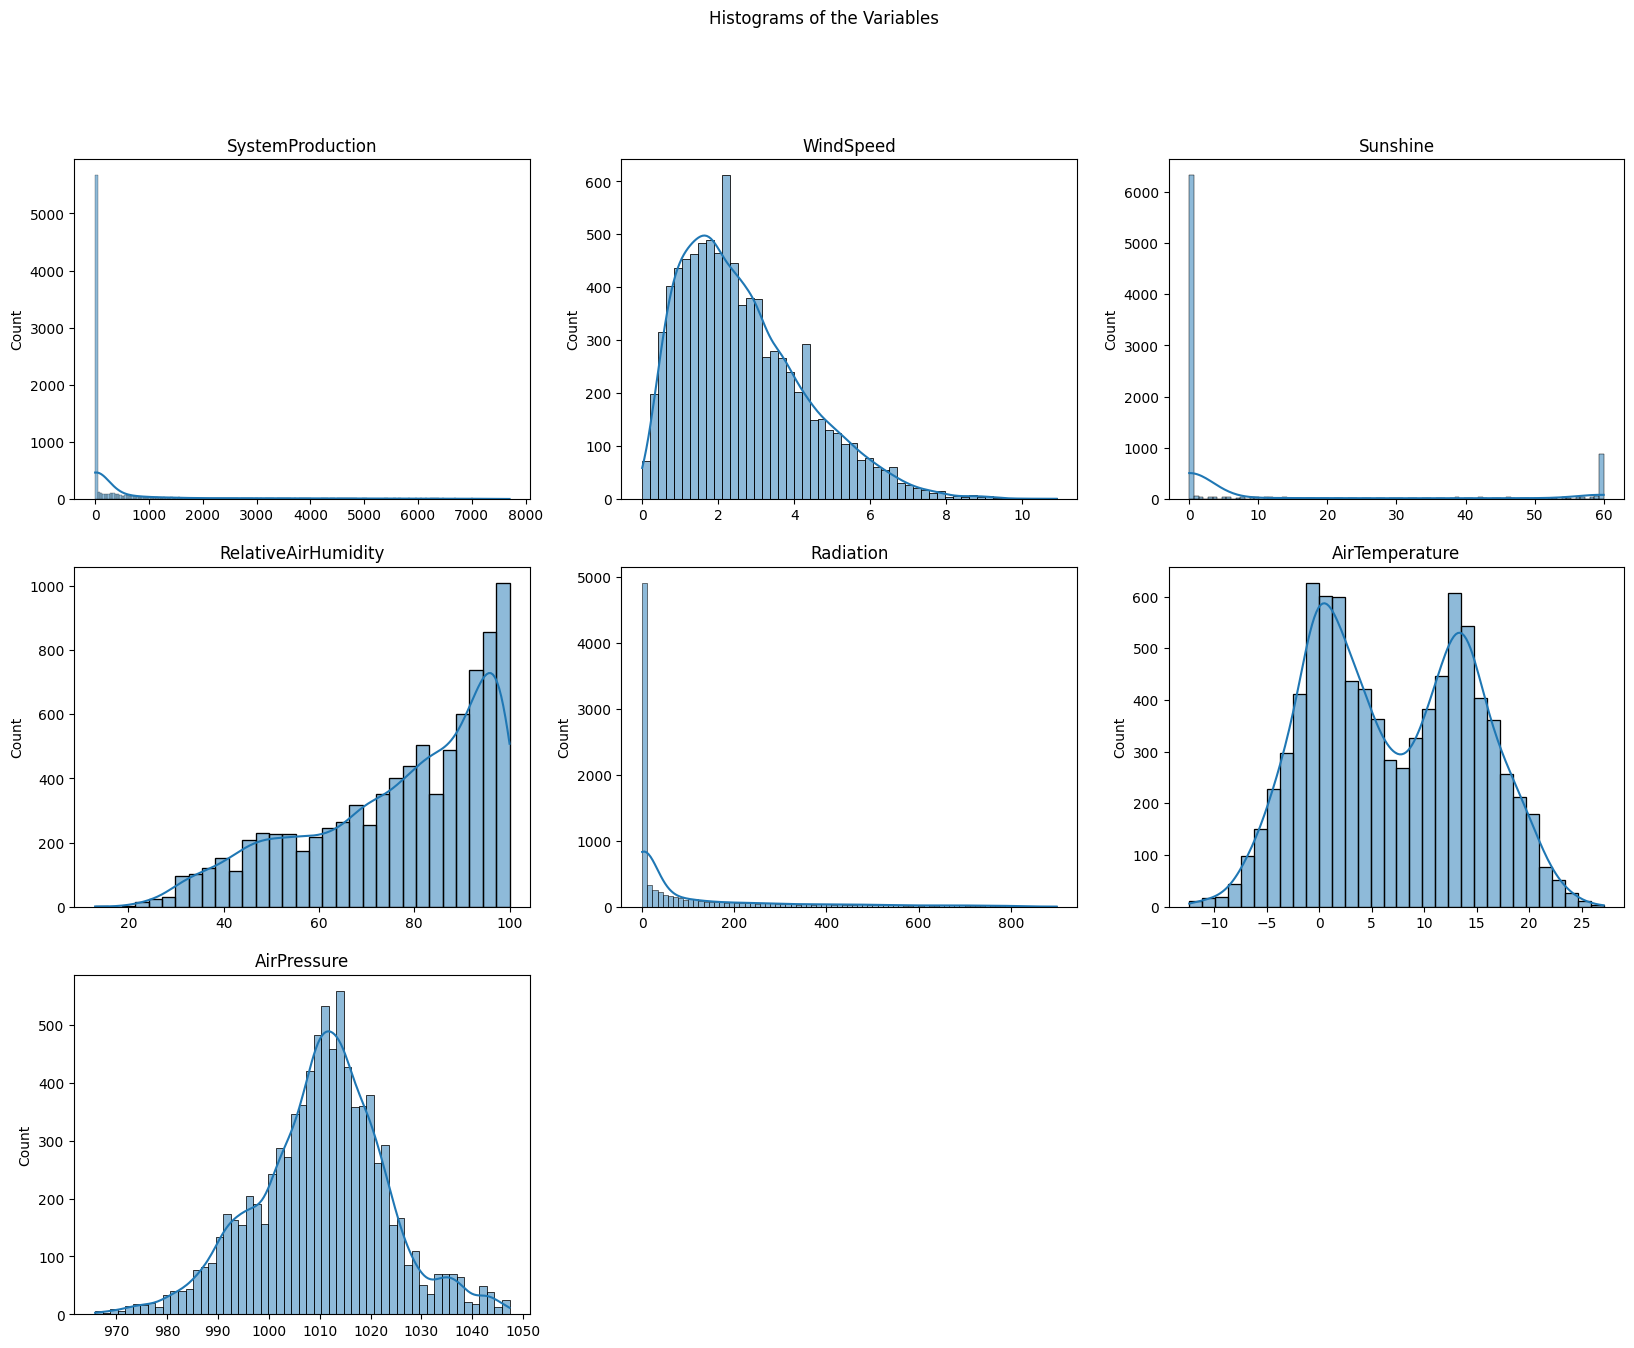

In [215]:
# Histograms:
fig, axes = plt.subplots(nrows=3, ncols=3, sharey=False, figsize=(20, 15))
fig.suptitle("Histograms of the Variables")
sns.histplot(df["SystemProduction"].values, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("SystemProduction")
sns.histplot(df["WindSpeed"].values, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("WindSpeed")
sns.histplot(df["Sunshine"].values, ax=axes[0][2], kde=True)
axes[0][2].set_title("Sunshine")
sns.histplot(df["RelativeAirHumidity"].values, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("RelativeAirHumidity")
sns.histplot(df["Radiation"].values, ax=axes[1, 1], kde=True, legend=False)
axes[1, 1].set_title("Radiation")
sns.histplot(df["AirTemperature"].values, ax=axes[1, 2], kde=True)
axes[1, 2].set_title("AirTemperature")
sns.histplot(df["AirPressure"].values, ax=axes[2, 0], kde=True)
axes[2, 0].set_title("AirPressure");
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

* There are few, but very high value outliers present in SystemProduction, Sun Shine and Radiation.
* Winspeed data is Right Skewed. Long tail toward high wind speed suggests rare natural events.
* Relative Air Humidity is left skewed, suggesting high humid climate of the location from where data is collected.
* Air pressure is approximately noramlly distributed.
* sunshine curve has peaks at two places, at zero or at 60 and very little values in the middle. This suggests that most of the time the sky is eaitheer fully blocked ir fully clear.

#### Normality test
Q--Q plots have been shown for visually representing the nomality districution of the data.

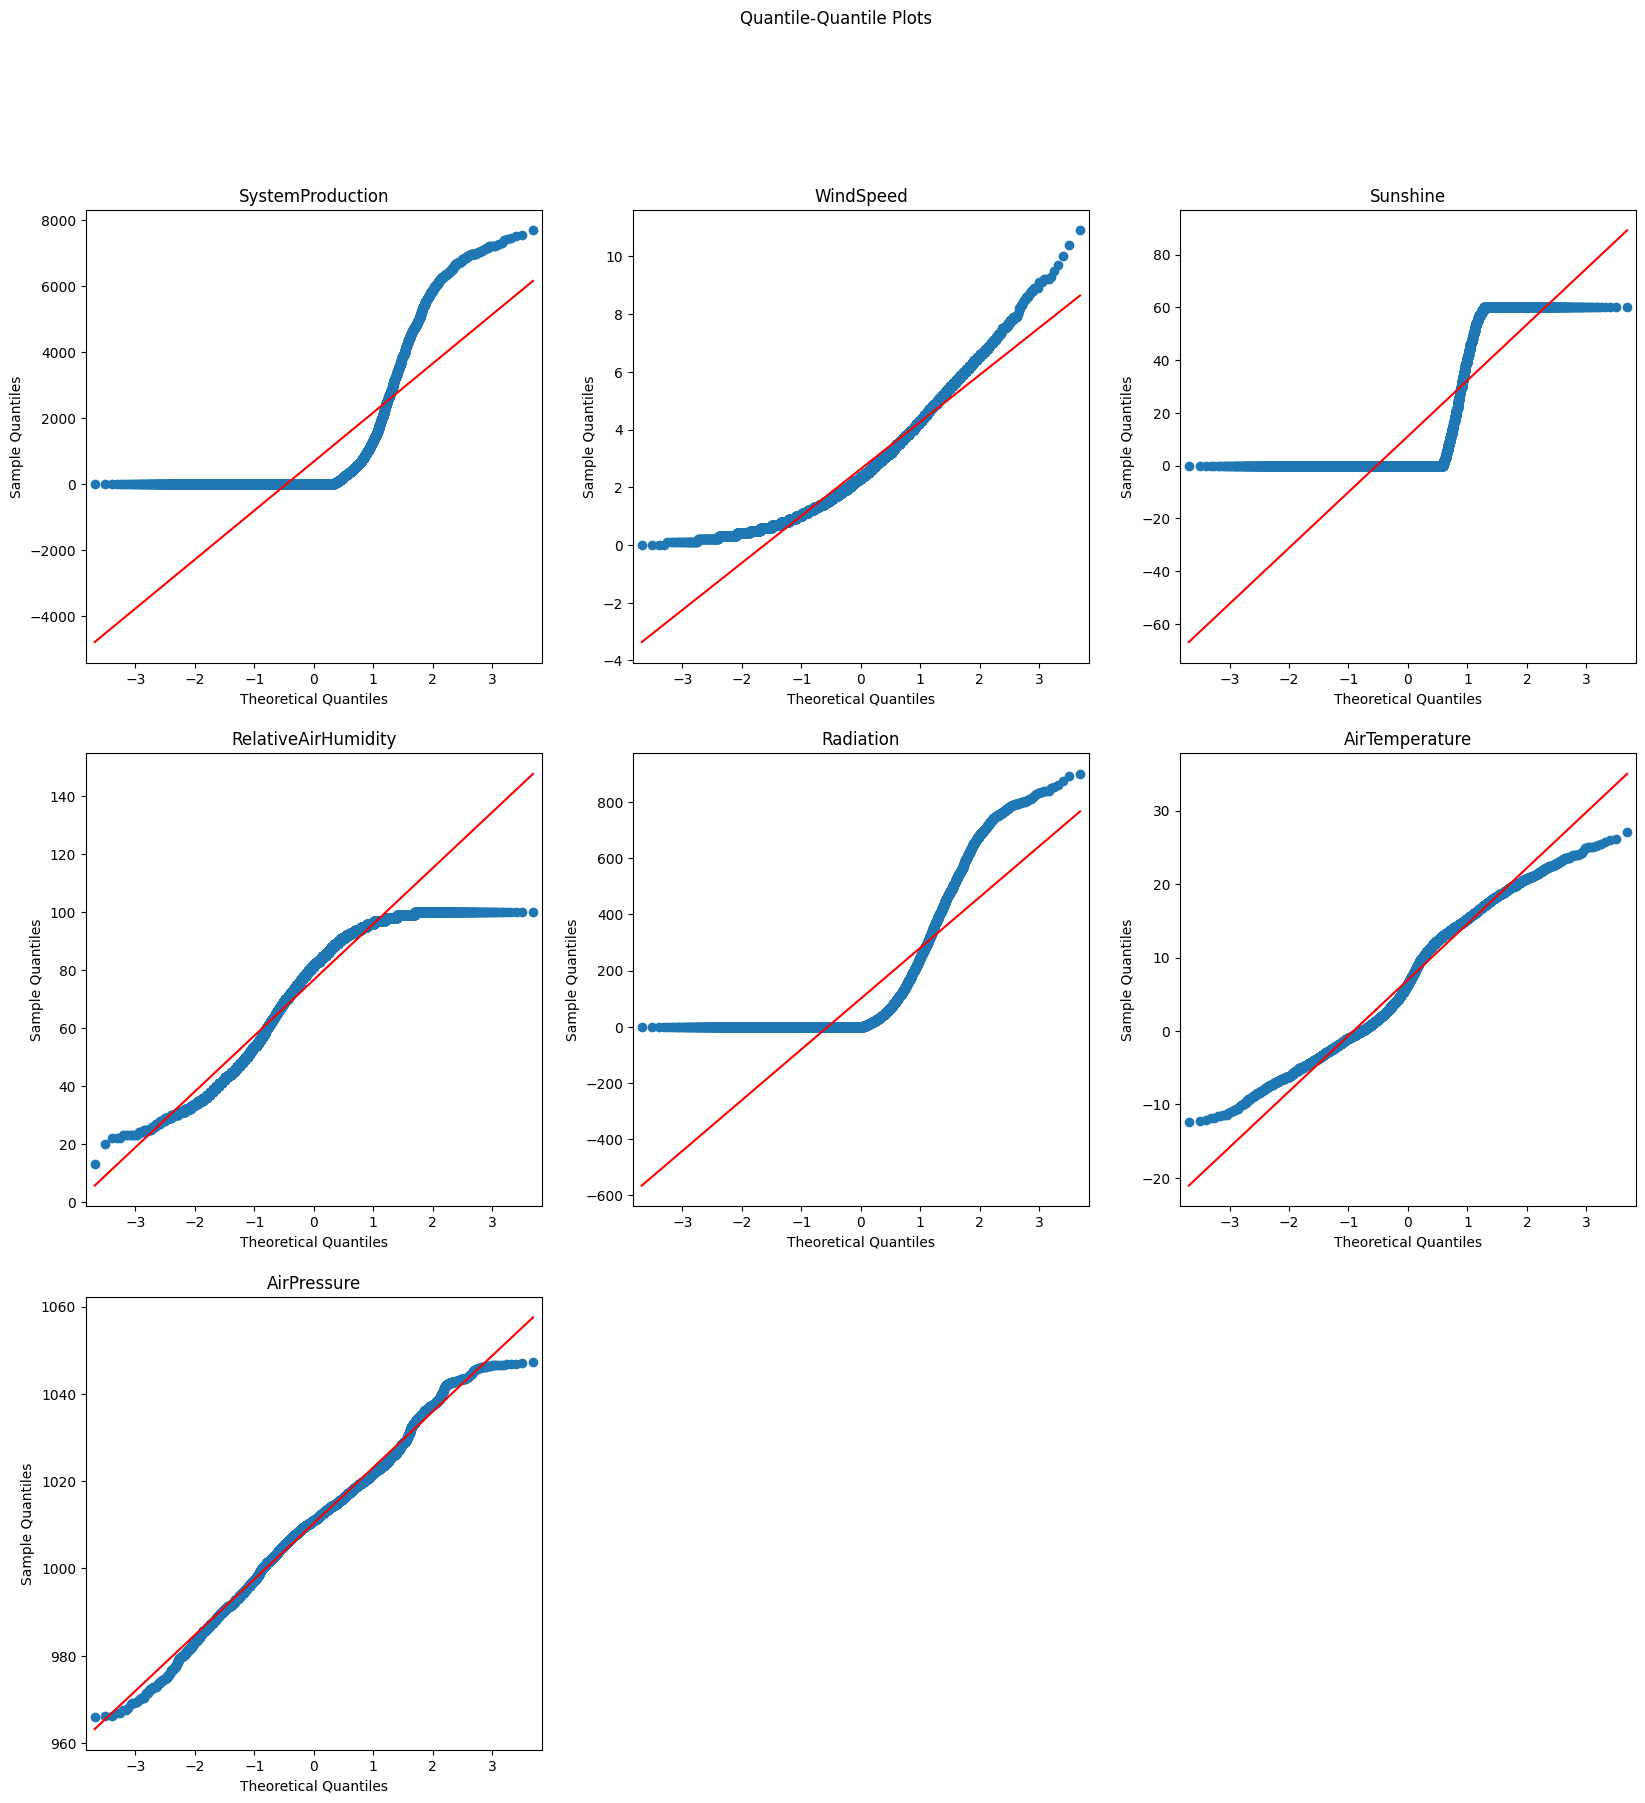

In [216]:
# QQ Plots:
# Defining subplots:
fig, axe = plt.subplots(3, 3, sharey=False, figsize=(20, 20))
fig.suptitle("Quantile-Quantile Plots")
# Plotting SystemProduction data:
qqplot(df["SystemProduction"], ax=axe[0, 0], line="s");
axe[0, 0].set_title("SystemProduction")
# Plotting WindSpeed data:
qqplot(df["WindSpeed"], ax=axe[0, 1], line="s")
axe[0, 1].set_title("WindSpeed")
# Plotting Sunshine data:
qqplot(df["Sunshine"], ax=axe[0, 2], line="s")
axe[0, 2].set_title("Sunshine")
# Ploting RelativeAirHumidity:
qqplot(df["RelativeAirHumidity"], ax=axe[1, 0], line="s")
axe[1, 0].set_title("RelativeAirHumidity")
# Radiation:
qqplot(df["Radiation"], ax=axe[1, 1], line="s")
axe[1, 1].set_title("Radiation")
# AirTemperature:
qqplot(df["AirTemperature"], ax=axe[1, 2], line="s")
axe[1, 2].set_title("AirTemperature")
# AirPressure
qqplot(df["AirPressure"], ax=axe[2, 0], line="s")
axe[2, 0].set_title("AirPressure");
axe[2, 1].set_visible(False)
axe[2, 2].set_visible(False)

As we can see from the qqplot and the Histogram above, it seems tha AirPressure follows a normal distribution. 

We can also quatify normality using statistical test. In this analysis, I have applied thrree method to test normality:
1. D'Agostino's K^2 test (skewness + kurtosis)
2. Lilliefors test (KS- based normality test)
3. Shapiro-Wilk test

Our Null Hypothesis assumption for the test will be:
* H0: Data was drew from a normal distribution.
* H1: Data was not drew from a normal distribution.
  
OBS: Using level of significance of 5% (alpha).

OBS2: Shapiro wilk p value is an approximate value due to the size of the sample being more than 5000.

In [217]:
#Function to calculate Shapiro-Wilk, Lilliefors and D'Agostino_K2 tests

def normality_test(df: any):
    test_names = ['Shapiro-Wilk', 'Lilliefors', "D'Agostino_K2"]
    extern_index = np.array(sorted(test_names*2))
    intern_index = np.array(["statistic", "p-value"]*len(test_names))

    mult_index = [
        extern_index, intern_index
    ]
    results = pd.DataFrame(index=mult_index, columns=df.columns)

    for c in df.columns:

        # D'Agostino's K-squared test
        k2, k2_p = normaltest(df[c])

        # Lillifors test
        lilliefors_result = lilliefors(df[c])
        ksstat, lilliefors_p = lilliefors_result

        # Shapiro-Wilk test
        shapiro_result = shapiro(df[c])
        shapiro_statistic, shapiro_p = shapiro_result.statistic, shapiro_result.pvalue
        results[c] = [k2, k2_p, ksstat, lilliefors_p, shapiro_statistic, shapiro_p]
    return results

In [218]:
# Function to calculate kurtosis and skewness
def skewness_kurtosis(dataset: any):
    index = ["Kurtosis", "Skewness"]
    results = pd.DataFrame(index=index, columns=dataset.columns)

    for c in dataset.columns:
        kurt = kurtosis(dataset[c])
        skewness = kurtosis(dataset[c])
        results[c] = [kurt, skewness]

    return results

In [219]:
normality_test(df)

C:\python 3.12\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8760.
  res = hypotest_fun_out(*samples, **kwds)


WindSpeed      Sunshine   AirPressure  \
D'Agostino_K2 statistic   9.806526e+02  2.095571e+03  6.722747e+01   
              p-value    1.132408e-213  0.000000e+00  2.521971e-15   
Lilliefors    statistic   8.657091e-02  4.224024e-01  4.527111e-02   
              p-value     1.000000e-03  1.000000e-03  1.000000e-03   
Shapiro-Wilk  statistic   9.421618e-01  5.596418e-01  9.922033e-01   
              p-value     7.391445e-50  3.679605e-91  1.630528e-21   

                            Radiation  AirTemperature  RelativeAirHumidity  \
D'Agostino_K2 statistic  3.498795e+03    2.245394e+03         7.997811e+02   
              p-value    0.000000e+00    0.000000e+00        2.136654e-174   
Lilliefors    statistic  2.887792e-01    8.151560e-02         1.136078e-01   
              p-value    1.000000e-03    1.000000e-03         1.000000e-03   
Shapiro-Wilk  statistic  6.283871e-01    9.712126e-01         9.158369e-01   
              p-value    3.204576e-87    1.368264e-38         1.556735e-56   

                         SystemProduction          Hour         Month  \
D'Agostino_K2 statistic      4.487421e+03  7.895778e+03  8.111891e+03   
              p-value        0.000000e+00  0.000000e+00  0.000000e+00   
Lilliefors    statistic      3.226334e-01  7.821483e-02  9.771358e-02   
              p-value        1.000000e-03  1.000000e-03  1.000000e-03   
Shapiro-Wilk  statistic      5.321172e-01  9.509604e-01  9.416028e-01   
              p-value        1.370636e-92  4.664639e-47  5.045971e-50   

                            DayOfYear  
D'Agostino_K2 statistic  7.598220e+03  
              p-value    0.000000e+00  
Lilliefors    statistic  5.856356e-02  
              p-value    1.000000e-03  
Shapiro-Wilk  statistic  9.548941e-01  
              p-value    1.136637e-45

For all variables, the null hypothesis of normality was rejected (p-value < 0.05).  
This result is expected given the **large sample size (N = 8760)**, as normality tests are known to be overly sensitive for large datasets.

> **Note:** For large samples, p-values alone are not sufficient indicators of distribution shape.

---


In [220]:
skewness_kurtosis(df)

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction,Hour,Month,DayOfYear
Kurtosis,0.645685,0.794225,0.413192,3.73561,-1.020777,-0.506118,5.930889,-1.204174,-1.207052,-1.200018
Skewness,0.645685,0.794225,0.413192,3.73561,-1.020777,-0.506118,5.930889,-1.204174,-1.207052,-1.200018


Distribution can be approximated to be symmetric when:
* Skewness between (-1, +1)

Distribution can be considered not heavy tailed when:
* Kurtosis between (-1, +1)

#### Correlation Matrix

<Axes: >

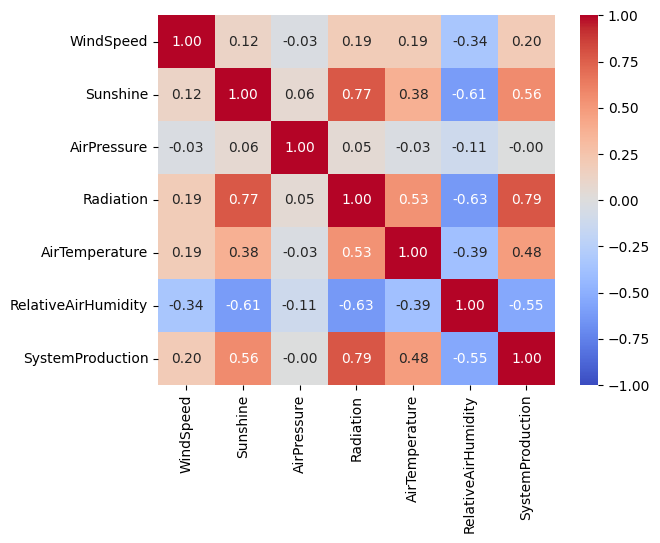

In [221]:
corr_df = df.drop(columns=['Month', 'Hour', 'DayOfYear'])
sns.heatmap(corr_df.corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm', fmt='.2f')

Conclusions

* Most of the data in SystemProduction is 0 as we expected since median is zero and the variable can't be negative.
* Outliers exist in SystemProduction, AirPressure, RelativeHumidity, Radiation, WindSpeed and Sunshine.
* All statistical tests have shown that the AirPressure not follows a normal distribution. However, all these tests are very sensitive when the sample size is large. So we can't rely on them.
* Histogram, QQ Plot, Kurtosis and Skewness tell us that AirPressue follows a normal distribution. Therefore, we will assume that AirPressure is normally distributed.
* Radiation has the highest positive correlation coefficient associated with the SystemProdution (0.79). It is also hightly correlated with Sushine column.
* RelativeAirHumidity has the lowest correlation coefficient associated with the Target. (-0.55)

# Preprocessing

In [222]:
# Seperate variables 
X= df.drop(columns=['SystemProduction', 'DayOfYear'])
y= df['SystemProduction']

In [223]:
# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature selection
Feature selection helps in
* Preventing Overfitting: Removes noise variables that lead to false patterns.
* Improves Efficiency: Faster training and lower memory usage.
* Boosts Accuracy: Helps the model focus only on the most predictive signals

There are multiple feature selection techniques, and each technique has its own limitations.  
Therefore, in this project, multiple feature selection methods were applied and their results were compared to ensure that no potentially important features were prematurely discarded.

Feature Selection Methods Used
* Filter (Univariate): Uses statistical test (F-score) to rank features by strength.
* Embedded (RF/XGB): Leverages tree-based logic to rank features during model training.
* Wrapper (RFECV): Recursively removes features and uses Cross-Validation to find the optimal subset for the lowest error.

In [224]:
# Feature Selection Class
class feature_selector:
    seed = 42
    def __init__(self, X, y):
        self.X_train = X
        self.y_train = y
        
    # function for feature selection using random forest
    def randomforest(self):
        model = RandomForestRegressor(random_state = feature_selector.seed)
        model.fit(self.X_train, self.y_train)
        #convert feature_importances_ array into a labeled series
        series = pd.Series(index=self.X_train.columns, data=model.feature_importances_)

        # plot Random FOrest Regressor feature inportances
        plt.title("Random Forest Importance")
        plt.xlabel("Importance")
        sns.barplot(x=series.values, y=series.index)

    # Function for XGBoost feature importance
    def xgbR_imp(self):
        model = XGBRegressor(random_state=feature_selector.seed)
        model.fit(self.X_train, self.y_train)
        series = pd.Series(index=self.X_train.columns, data=model.feature_importances_)

        # Plot XGBoost feature importance
        plt.title("XGBoost Feature Importance")
        plt.xlabel("Importance")
        sns.barplot(y=series.index, x=series.values)
                           

    # Univariate feature selector
    def univariate(self, statistic, n='all'):
        # select top k feature based on statistical test
        selector = SelectKBest(score_func=statistic, k=n)
        selector.fit(self.X_train, self.y_train)
        series = (pd.Series(index=self.X_train.columns, data=selector.scores_)
                  .sort_values(ascending=True))

        # plot univariate feature importance
        plt.title("F-Regression Filtering")
        plt.xlabel("F-score")
        sns.barplot(y=series.index, x=series.values)

        #return the fitted selector
        return selector

    # Recursive feature elimination with cross-validation (Wrapper method)
    def refcv(self):
        # list all the models
        models = {
            "Lasso": Lasso(random_state=feature_selector.seed),
            "Ridge": Ridge(random_state=feature_selector.seed),
            "RandomForestR": RandomForestRegressor(random_state=feature_selector.seed),
            "ExtraTreeR": ExtraTreesRegressor(random_state=feature_selector.seed),
            "XGB": XGBRegressor(random_state=feature_selector.seed),
        }
        splits=10
        cross = KFold(n_splits=splits, random_state=feature_selector.seed, shuffle=True)
        ind = [f"Columns {i}" for i in range(1,len(self.X_train.columns)+1)]
        df = pd.DataFrame(index=ind)

        minimo = np.inf
        name = ""
        for key, model in models.items():
            rfecv = RFECV(estimator=model, step=1, cv=cross, min_features_to_select=1, scoring='neg_mean_squared_error')
            rfecv.fit(self.X_train, self.y_train)
            root_mean = np.sqrt(-rfecv.cv_results_["mean_test_score"])
            df[key] = root_mean
            best_value = root_mean[np.argmin(root_mean)]

            if minimo>best_value:
                minimo = best_value
                best_features = rfecv.support_
                name = key


        df_features = pd.DataFrame(columns=self.X_train.columns, data=best_features.reshape(1, -1))
        return df, df_features
        
        
        

In [225]:
# feature selector object
feature = feature_selector(X_train, y_train)

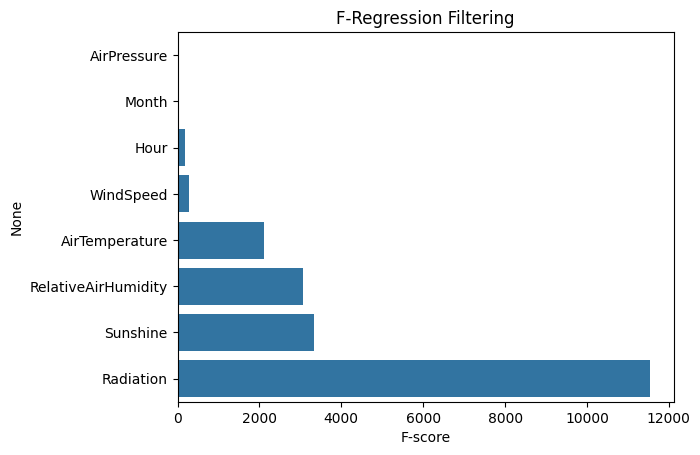

In [226]:
# filter feature selection using f_regression test
selector_filtering = feature.univariate(statistic=f_regression)

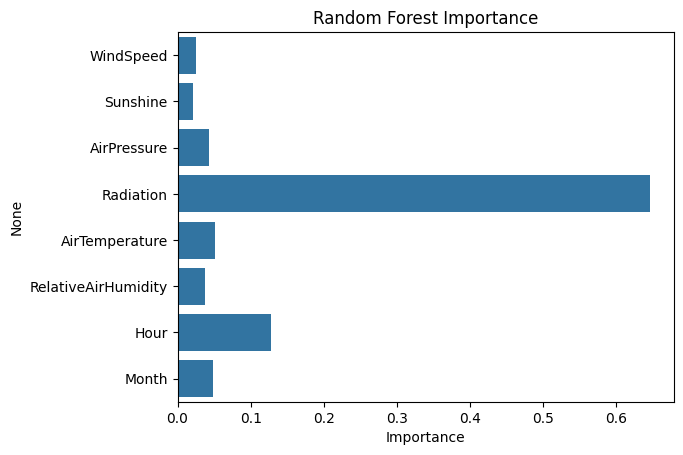

In [227]:
feature.randomforest()

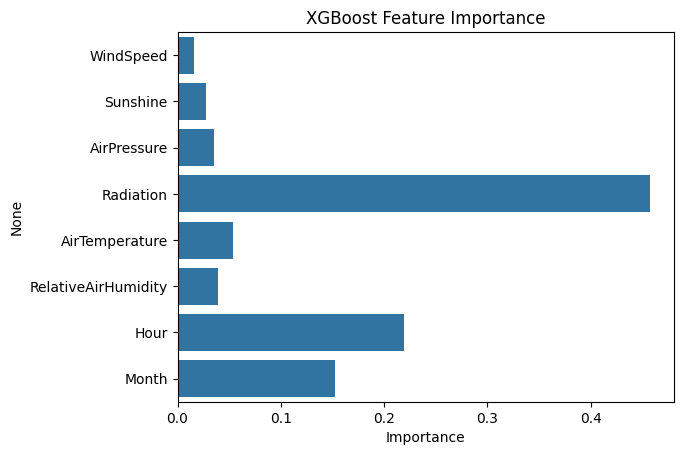

In [228]:
feature.xgbR_imp()

In [229]:
# mean test score for all of the algorithms and for each number of columns
df_results, df_features= feature.refcv()
df_results

,Lasso,Ridge,RandomForestR,ExtraTreeR,XGB
Columns 1,1467.860960,1477.986141,1133.236462,1209.060237,953.840207
Columns 2,1301.266660,1312.583376,892.082412,1089.944009,884.631516
Columns 3,1155.614811,1158.127170,800.691557,844.815127,772.942631
Columns 4,1124.590002,1124.589720,690.990391,759.669027,688.124555
Columns 5,1121.988939,1121.988692,592.740265,712.619283,645.347799
Columns 6,900.605792,900.605673,590.468229,613.548644,604.088487
Columns 7,898.482616,898.482611,594.294940,577.655364,595.430303
Columns 8,898.507997,898.508050,590.857420,572.988429,592.144239


In [230]:
df_features

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,Hour,Month
0,True,True,True,True,True,True,True,True


As the number of features is increases, RMSE decreases. Best result being with columns=8 and Model = ExtraTrees.

#### Transformation

In [231]:
# MinMax Scaler Transformation
min_max = MinMaxScaler()
X_train_MM = min_max.fit_transform(X_train)
X_test_MM = min_max.transform(X_test)

In [232]:
# Standard Scaler Transformation
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [233]:
# Robust Scaler Transformation
rob = RobustScaler()
X_train_rb = rob.fit_transform(X_train)
X_test_rob = rob.transform(X_test)

In [234]:
# Function to evaluate best algorithm
def best_model(X_train, y_train):
    seed = 42
    cv = 5
    score = ['neg_root_mean_squared_error', 'r2']
    result_rmse = {}
    result_r2 = {}

    model_dict = {
        'Lasso': Lasso(random_state = seed), 
        'Ridge': Ridge(random_state = seed),
        'SVR': SVR(),
        'RandomForestR': RandomForestRegressor(random_state= seed),
        'ExtraTreeR': ExtraTreesRegressor(random_state=seed),
        'XFB': XGBRegressor(random_state=seed),
        'MLP': MLPRegressor(random_state=seed, max_iter=2000)
    }

    for name, model in model_dict.items():
        k_fold = KFold(n_splits=cv, random_state=seed, shuffle=True)
        result = cross_validate(model, X_train, y_train, cv=k_fold, scoring=score)
        result_rmse[name] = -result['test_neg_root_mean_squared_error']
        result_r2[name] = result['test_r2']
        result_pd_rmse = pd.DataFrame(data=result_rmse)
        result_pd_r2 = pd.DataFrame(data=result_r2)

    return result_pd_rmse, result_pd_r2

In [235]:
# Evaluate best model result using stansard scaler
result_rms, result_r2 = best_model(X_train_std, y_train)

In [236]:
result_rms.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,898.282186,898.278285,1532.740724,597.905718,582.773551,608.169964,789.084046
std,15.930973,15.948231,77.034620,30.271211,37.426480,42.129370,21.341540
min,877.561941,877.521020,1410.485799,553.820770,538.992337,560.736325,763.293850
25%,892.171275,892.079508,1510.996709,581.819518,546.554494,566.475676,778.438116
50%,893.345236,893.434418,1559.397350,604.900485,601.780855,626.604575,786.435884
75%,911.041166,911.094793,1572.397723,624.078122,604.523544,631.842629,796.952037
max,917.291309,917.261684,1610.426041,624.909697,622.016524,655.190613,820.300343


In [237]:
result_r2.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.642484,0.642489,-0.036970,0.841804,0.849203,0.835763,0.724282
std,0.025589,0.025553,0.015298,0.012452,0.019202,0.021817,0.018395
min,0.605038,0.605074,-0.054832,0.833394,0.834934,0.816857,0.701198
25%,0.641018,0.641041,-0.049128,0.833836,0.837716,0.824052,0.712919
50%,0.643307,0.643381,-0.037453,0.836030,0.844086,0.829676,0.728452
75%,0.645896,0.645854,-0.023116,0.842696,0.846797,0.835425,0.729031
max,0.677161,0.677097,-0.020323,0.863062,0.882480,0.872807,0.749808


<Axes: title={'center': "Model's Performance - Standard Scaler"}>

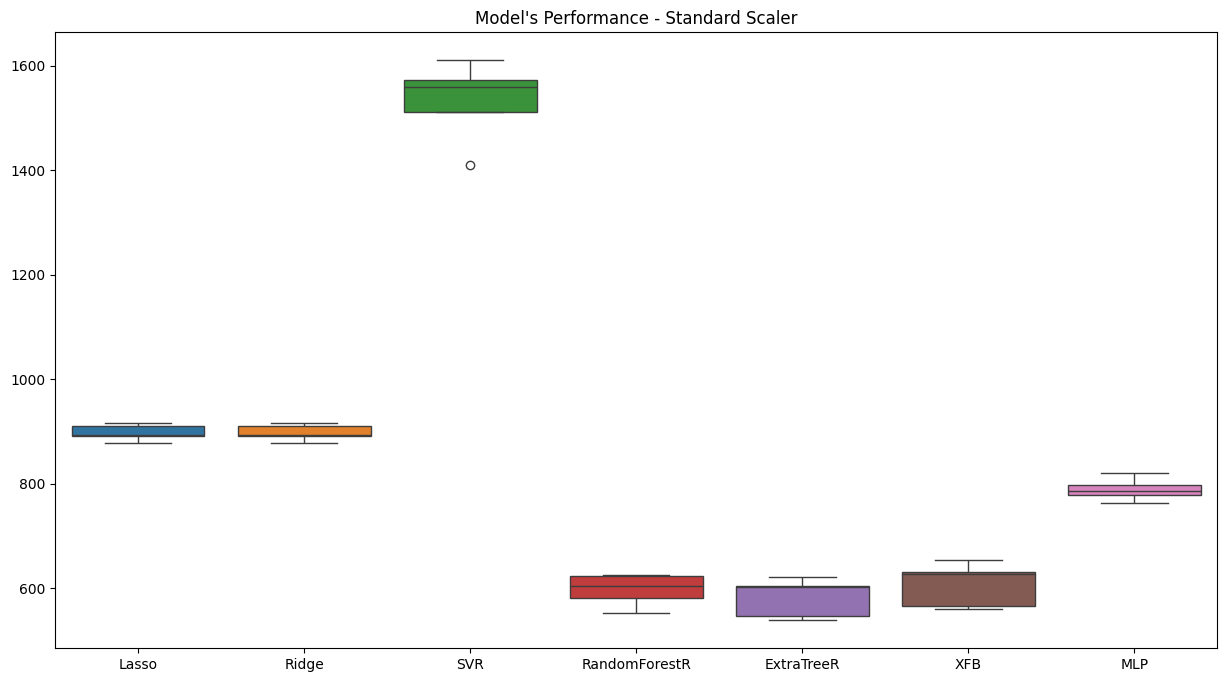

In [238]:
# Plot model performance
plt.figure(figsize = (15,8))
plt.title("Model's Performance - Standard Scaler")
sns.boxplot(result_rms)

In [239]:
# Evaluate best model using robust scaler
result_rms, result_r2 = best_model(X_train_rb, y_train)
result_rms.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,898.272830,898.277921,1490.923637,597.989529,582.685690,608.169964,793.672910
std,15.942177,15.947717,78.055054,30.218379,37.555247,42.129370,20.658702
min,877.590044,877.531604,1365.791913,554.020148,538.553034,560.736325,771.695842
25%,892.099396,892.069101,1473.190192,582.277179,546.554494,566.475676,779.715099
50%,893.295175,893.426057,1515.854339,604.141530,601.780855,626.604575,789.042560
75%,911.087481,911.101124,1529.616090,623.791551,604.523544,631.842629,804.335052
max,917.292051,917.261717,1570.165649,625.717238,622.016524,655.190613,823.575995


In [240]:
result_r2.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.642490,0.642489,0.018978,0.841765,0.849241,0.835763,0.720980
std,0.025610,0.025558,0.017506,0.012363,0.019285,0.021817,0.019965
min,0.605012,0.605065,0.001787,0.832964,0.834934,0.816857,0.694583
25%,0.641017,0.641041,0.002672,0.833989,0.837716,0.824052,0.710622
50%,0.643365,0.643389,0.019676,0.836441,0.844086,0.829676,0.723987
75%,0.645860,0.645849,0.027442,0.842583,0.846797,0.835425,0.727561
max,0.677197,0.677103,0.043314,0.862847,0.882671,0.872807,0.748147


[]

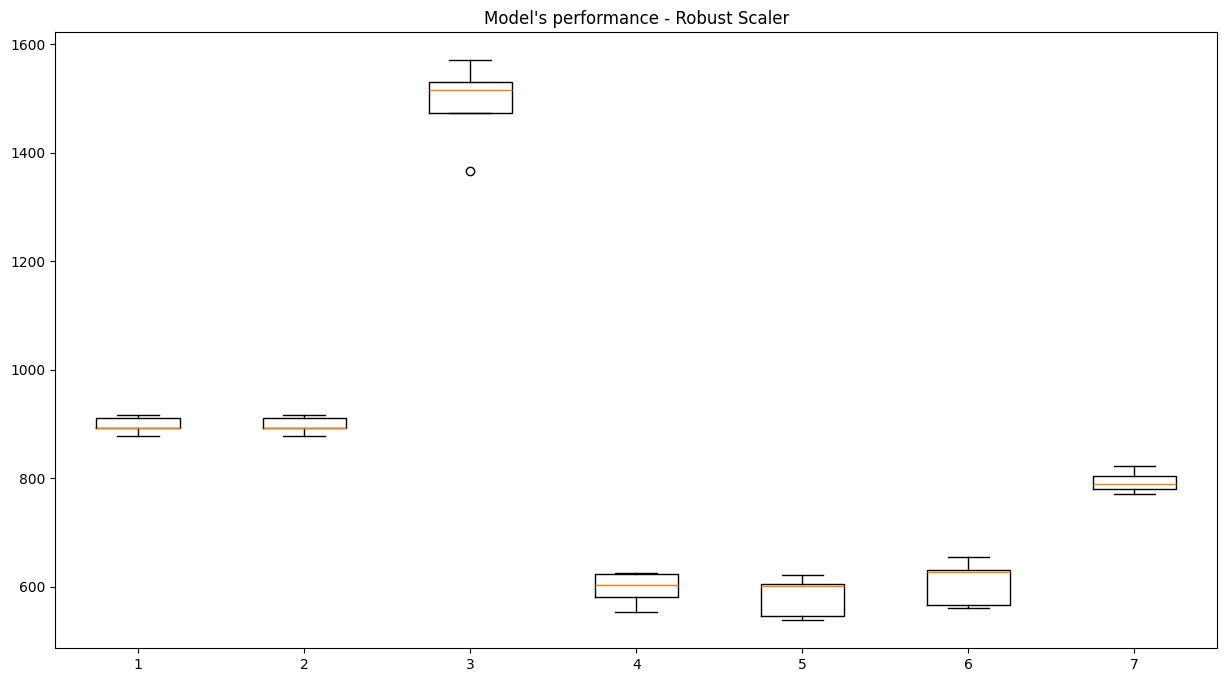

In [241]:
# Plot model performance
plt.figure(figsize=(15, 8))
plt.title("Model's performance - Robust Scaler")
plt.boxplot(result_rms)
plt.plot()

In [242]:
# Evaluate best model using MinMaxScaler
result_rms, result_r2 = best_model(X_train_MM, y_train)
result_rms.describe()

C:\python 3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\python 3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\python 3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,898.391468,898.327905,1509.288413,597.933560,582.685690,608.169964,878.327175
std,15.899473,15.971473,76.382531,30.333480,37.555247,42.129370,32.394625
min,877.695116,877.176343,1386.893083,554.224595,538.553034,560.736325,852.253441
25%,892.600132,892.497831,1492.631095,581.687994,546.554494,566.475676,853.804269
50%,893.215395,893.747930,1532.381736,603.771336,601.780855,626.604575,858.309674
75%,910.967135,910.952000,1546.988818,623.030185,604.523544,631.842629,910.275992
max,917.479562,917.265420,1587.547336,626.953690,622.016524,655.190613,916.992497


In [243]:
result_r2.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XFB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.642392,0.642461,-0.005447,0.841786,0.849241,0.835763,0.658109
std,0.025667,0.025364,0.014693,0.012518,0.019285,0.021817,0.029638
min,0.604918,0.605385,-0.021016,0.832303,0.834934,0.816857,0.627490
25%,0.640870,0.641038,-0.019531,0.834394,0.837716,0.824052,0.641252
50%,0.642964,0.643046,-0.001818,0.836641,0.844086,0.829676,0.646491
75%,0.645954,0.645965,0.001604,0.842467,0.846797,0.835425,0.673326
max,0.677255,0.676870,0.013525,0.863124,0.882671,0.872807,0.701987


[]

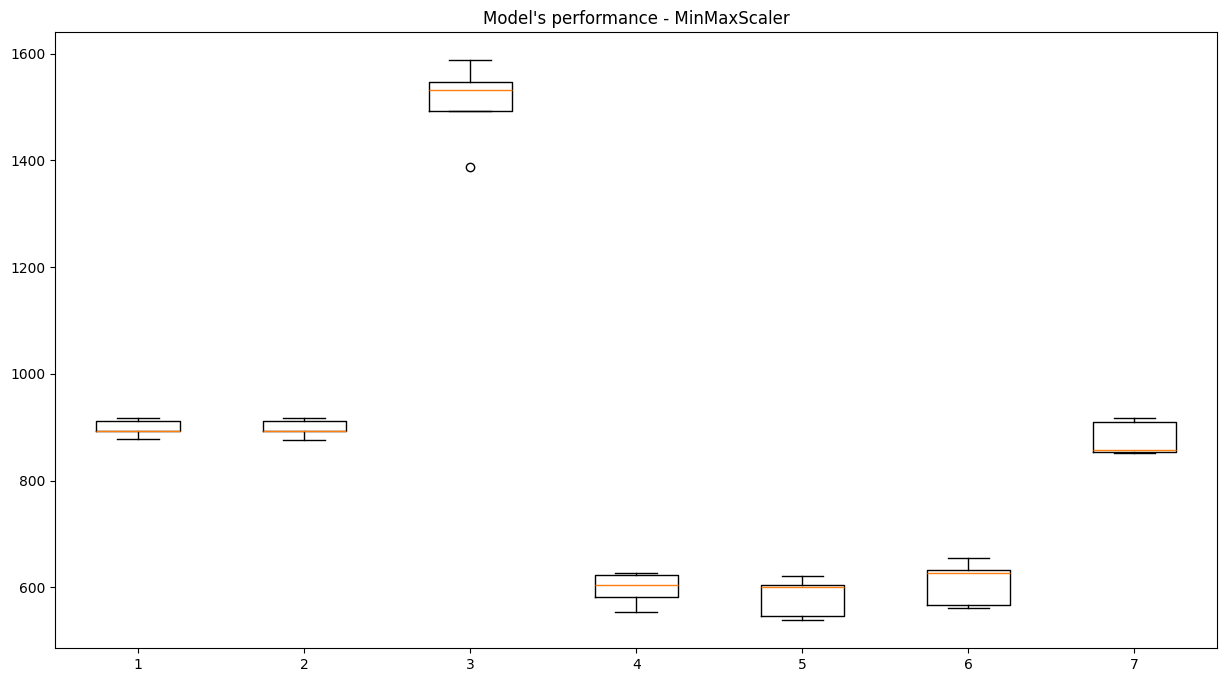

In [244]:
# plot model performance
plt.figure(figsize=(15,8))
plt.title("Model's performance - MinMaxScaler")
plt.boxplot(result_rms)
plt.plot()

* ExtraTres was the best Algorithm for all of the algorithms.
* The Best Trasformation algorithm was Robust Scaler.

In [245]:
# Function for fine tuning 
def tuning(X_train, y_train, model, params):
    cv = 5
    score = "neg_root_mean_squared_error"

    grid = GridSearchCV(model, cv=cv, param_grid=params, scoring=score, n_jobs=-1,
                       return_train_score=True)
    grid.fit(X_train, y_train)

    best_index = grid.best_index_
    result = grid.cv_results_

    train_score = -result['mean_train_score'][best_index]
    left_out = -result['mean_test_score'][best_index]

    print(f"Train score: {train_score}")
    print(f"Left out data score: {left_out}")

    return grid.best_estimator_

In [246]:
def save_model(model):
    try:
        joblib.dump(model, "model/extra_tree_model.joblib")
    except:
        os.makedirs('model')
        path = "model/extra_tree_model.joblib"
        joblib.dump(model, path)

In [247]:
# hyperparameter grid:
params = {"n_estimators":[100, 110, 120],
         "max_depth": [4, 5, 6, 7],
         "min_samples_split":[3, 5, 6, 7, 10]}

In [248]:
# Fine tuning on ExtraTreeRegressor:
extra_tree = ExtraTreesRegressor(random_state=42)
best_estimator = tuning(X_train_rb, y_train, extra_tree, params)

Train score: 598.7328672451029
Left out data score: 671.7753543519966


In [249]:
save_model(best_estimator)

# Prediction

In [250]:
best_model = clone(best_estimator)
best_model.fit(X_train_rb, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [251]:
# Computing Metrics for the training set:
y_pred = best_model.predict(X_train_rb)
rms_train = np.sqrt(mean_squared_error(y_pred, y_train))
r2_train = r2_score(y_pred, y_train)
print("Train set:")
print(f"RMSE: {rms_train}")
print(f"R2: {r2_train}")

Train set:
RMSE: 616.8653551805002
R2: 0.7655478690202446


## Conclusions
* RMSE improved from 835.595 to 819.731.
* R2 score is approximately 0.765.
* Model does not seem to suffer from Overfitting.